In [1]:
import os
import glob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

In [2]:
def load_dataset(base_path):
    texts, labels = [], []
    
    # Đọc bình luận tích cực (label = 1)
    pos_path = os.path.join(base_path, 'pos', '*.txt')
    for file_path in glob.glob(pos_path):
        with open(file_path, 'r', encoding='utf-8') as f:
            texts.append(f.read().strip())
        labels.append(1)
        
    # Đọc bình luận tiêu cực (label = 0)
    neg_path = os.path.join(base_path, 'neg', '*.txt')
    for file_path in glob.glob(neg_path):
        with open(file_path, 'r', encoding='utf-8') as f:
            texts.append(f.read().strip())
        labels.append(0)
        
    return texts, labels
# Định nghĩa đường dẫn tuyệt đối đến thư mục chứa data
train_dir = r"d:\dut_ai\AIO_code\spare representation\data\data_train\train"
test_dir = r"d:\dut_ai\AIO_code\spare representation\data\data_test\test"
print("1. Đang tải dữ liệu...")
X_train, y_train = load_dataset(train_dir)
X_test, y_test = load_dataset(test_dir)
print(f"-> Số lượng mẫu huấn luyện: {len(X_train)}")
print(f"-> Số lượng mẫu kiểm thử: {len(X_test)}")

1. Đang tải dữ liệu...The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.

-> Số lượng mẫu huấn luyện: 30000
-> Số lượng mẫu kiểm thử: 10000


In [3]:
import string
import nltk
from nltk import ngrams
nltk.download('punkt') 
nltk.download('punkt_tab')
def nltk_ngram_tokenizer(text):
    
    # 1. TIỀN XỬ LÝ (Preprocessing): Chuyển toàn bộ về chữ thường
    text = text.lower()
    
    # 2. TOKENIZATION: Tách từ 
    tokens = nltk.word_tokenize(text)
    
    # 3. TIỀN XỬ LÝ MỞ RỘNG: Lọc bỏ các dấu câu (,.!?;:...) sinh ra trong quá trình tokenize 
    tokens = [word for word in tokens if word not in string.punctuation]
    
    # 4. TẠO MÔ HÌNH N-GRAMS
    unigrams = list(ngrams(tokens, 1))
    bigrams  = list(ngrams(tokens, 2))
    trigrams = list(ngrams(tokens, 3))
    
    all_ngrams = unigrams + bigrams + trigrams
    
    # Khâu nối lại để tương thích với các thuật toán Machine Learning
    return [' '.join(gram) for gram in all_ngrams]

print(nltk_ngram_tokenizer("Quán này làm Bingsu thập_cẩm rất ngon !!!"))

['quán', 'này', 'làm', 'bingsu', 'thập_cẩm', 'rất', 'ngon', 'quán này', 'này làm', 'làm bingsu', 'bingsu thập_cẩm', 'thập_cẩm rất', 'rất ngon', 'quán này làm', 'này làm bingsu', 'làm bingsu thập_cẩm', 'bingsu thập_cẩm rất', 'thập_cẩm rất ngon']


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\khacb\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\khacb\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [4]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
from sklearn.feature_extraction.text import TfidfTransformer

pipeline_bai2 = Pipeline([
    ('vectorizer', CountVectorizer(
        tokenizer=nltk_ngram_tokenizer,    
        token_pattern=None
    )), 
    ('tfidf', TfidfTransformer()),         # BIẾN ĐỔI TF-IDF (Phạt các từ vô nghĩa)
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, verbose=1))  
])

In [5]:
from tqdm import tqdm 

print("1. Đang nạp N-gram + TF-IDF Features và Train mô hình...")
pipeline_bai2.fit(tqdm(X_train, desc="Tokenize & TF-IDF Extraction"), y_train)
print(f"-> Huấn luyện Bài 2 hoàn tất!\n")
# DỰ ĐOÁN VÀ ĐÁNH GIÁ (EVALUATE)
print("2. Đang đưa tập kiểm thử (Test) vào dự đoán...\n")
y_pred_2 = pipeline_bai2.predict(X_test)
print(f"========== KẾT QUẢ ĐÁNH GIÁ BÀI 2 ==========")
print(f"⭐ Độ chính xác tổng thể (Accuracy): {accuracy_score(y_test, y_pred_2) * 100:.2f}%\n")
print("Chi tiết Báo cáo Phân loại:")
print(classification_report(y_test, y_pred_2, target_names=['Tiêu cực (0)', 'Tích cực (1)']))

1. Đang nạp N-gram + TF-IDF Features và Train mô hình...


Tokenize & TF-IDF Extraction: 100%|██████████| 30000/30000 [00:34<00:00, 881.97it/s] 


-> Huấn luyện Bài 2 hoàn tất!

2. Đang đưa tập kiểm thử (Test) vào dự đoán...

========== KẾT QUẢ ĐÁNH GIÁ BÀI 2 ==========
⭐ Độ chính xác tổng thể (Accuracy): 89.09%

Chi tiết Báo cáo Phân loại:
              precision    recall  f1-score   support

Tiêu cực (0)       0.91      0.87      0.89      5000
Tích cực (1)       0.88      0.91      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



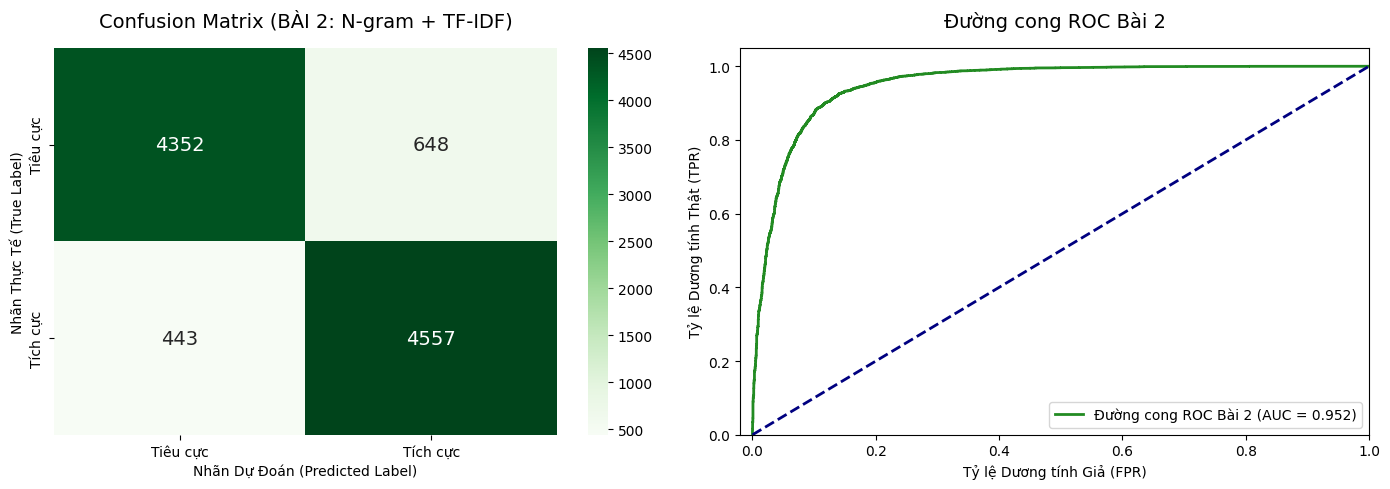

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
cm_2 = confusion_matrix(y_test, y_pred_2)
y_pred_proba_2 = pipeline_bai2.predict_proba(X_test)[:, 1] 
fpr_2, tpr_2, thresholds_2 = roc_curve(y_test, y_pred_proba_2)
roc_auc_2 = auc(fpr_2, tpr_2)
plt.figure(figsize=(14, 5))
# Đồ thị Ma trận nhầm lẫn
plt.subplot(1, 2, 1)
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Tiêu cực', 'Tích cực'], 
            yticklabels=['Tiêu cực', 'Tích cực'],
            annot_kws={"size": 14})
plt.title('Confusion Matrix (BÀI 2: N-gram + TF-IDF)', fontsize=14, pad=15)
plt.ylabel('Nhãn Thực Tế (True Label)')
plt.xlabel('Nhãn Dự Đoán (Predicted Label)')
# Đồ thị vòng cung ROC
plt.subplot(1, 2, 2)
plt.plot(fpr_2, tpr_2, color='forestgreen', lw=2, label=f'Đường cong ROC Bài 2 (AUC = {roc_auc_2:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tỷ lệ Dương tính Giả (FPR)')
plt.ylabel('Tỷ lệ Dương tính Thật (TPR)')
plt.title('Đường cong ROC Bài 2', fontsize=14, pad=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()